# ============================================================
 FIFA WORLD CUP 2026 - BALL POSSESSION ANALYSIS

 Analytic Question:
 Is there a significant difference in the average
 ball possession percentage between winning and
 losing teams in FIFA World Cup 2026 matches?
# ============================================================

In [1]:
# ============================================================
# Import libraries
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats as st

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ============================================================
# Load dataset
# ============================================================

file_path = "FIFA_WC2026_Possession_Final_Sample.csv"
df_sample = pd.read_csv(file_path)

# Check rows and columns of dataset
print("Rows:", df_sample.shape[0])
print("Columns:", df_sample.shape[1])

# View dataset info
print("\n----First 5 rows: ----")
print(df_sample.head())
print("\n")
print(df_sample.info())

Rows: 80
Columns: 5

----First 5 rows: ----
   MatchID                   Match         Team Result  Ball_Possession_pct
0       44       Jordan vs Algeria      Algeria    Win                   72
1        1  Mexico vs South Africa       Mexico    Win                   61
2       33   Netherlands vs Sweden  Netherlands    Win                   51
3       45  Portugal vs Uzbekistan     Portugal    Win                   66
4       29        USA vs Australia          USA    Win                   62


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   MatchID              80 non-null     int64 
 1   Match                80 non-null     object
 2   Team                 80 non-null     object
 3   Result               80 non-null     object
 4   Ball_Possession_pct  80 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 3.3+ KB
Non

In [3]:
# ============================================================
# Separate the sample data into two groups: winning and losing teams
# ============================================================

winners = df_sample[df_sample["Result"] == "Win"]["Ball_Possession_pct"]
losers = df_sample[df_sample["Result"] == "Loss"]["Ball_Possession_pct"]

print("Winning teams:", len(winners))
print("Losing teams:", len(losers))

Winning teams: 40
Losing teams: 40


In [4]:
# ============================================================
# 95% Confidence Interval of sample data
# ============================================================

# Calculate mean for each group
win_mean = winners.mean()
loss_mean = losers.mean()

# Calculate standard deviation for each group
win_std = winners.std()
loss_std = losers.std()

# Calculate sample size for each group
n_win = len(winners)
n_loss = len(losers)

# Calculate standard error for each group
win_se = win_std / np.sqrt(n_win)
loss_se = loss_std / np.sqrt(n_loss)

# Calculate 95% confidence interval for winning teams
win_ci_low, win_ci_upp = st.t.interval(
    confidence=0.95,
    df=n_win - 1,
    loc=win_mean,
    scale=win_se
)

# Calculate 95% confidence interval for losing teams
loss_ci_low, loss_ci_upp = st.t.interval(
    confidence=0.95,
    df=n_loss - 1,
    loc=loss_mean,
    scale=loss_se
)

# Display results
print("95%% Confidence Interval of Winning Teams: %.2f to %.2f"
      % (win_ci_low, win_ci_upp))

print("95%% Confidence Interval of Losing Teams: %.2f to %.2f"
      % (loss_ci_low, loss_ci_upp))

95% Confidence Interval of Winning Teams: 55.19 to 61.81
95% Confidence Interval of Losing Teams: 42.49 to 49.61


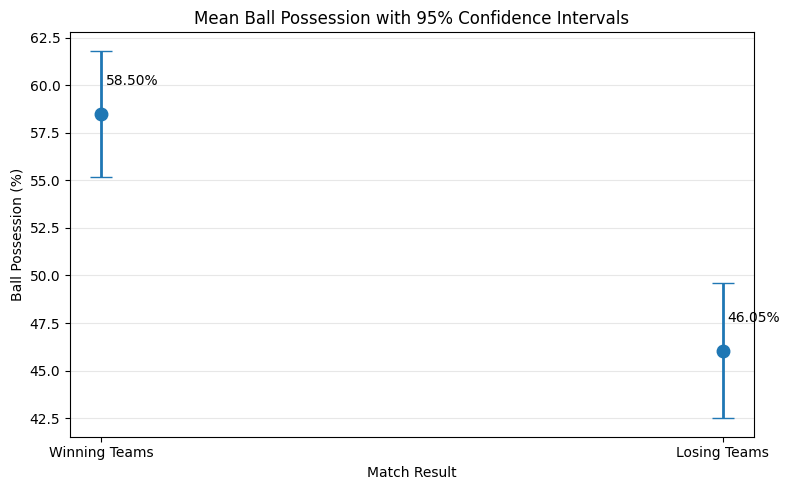

In [5]:
# ============================================================
# Plot Mean Ball Possession with 95% Confidence Intervals
# ============================================================

# Group names and means
groups = ["Winning Teams", "Losing Teams"]
means = [win_mean, loss_mean]

# Calculate CI error distances from the mean
ci_errors = [
    [win_mean - win_ci_low, loss_mean - loss_ci_low],
    [win_ci_upp - win_mean, loss_ci_upp - loss_mean]
]

plt.figure(figsize=(8, 5))

# Plot means with 95% CI error bars
plt.errorbar(
    groups,
    means,
    yerr=ci_errors,
    fmt="o",
    capsize=8,
    markersize=9,
    linewidth=2
)

# Add mean labels
for i, mean in enumerate(means):
    plt.text(
        i + 0.05,
        mean + 1.5,
        f"{mean:.2f}%",
        ha="center",
        fontsize=10
    )

# Labels and title
plt.ylabel("Ball Possession (%)")
plt.xlabel("Match Result")
plt.title("Mean Ball Possession with 95% Confidence Intervals")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 95% Confidence Interval for Difference in Means
# ============================================================

mean_diff = win_mean - loss_mean

se_diff = np.sqrt(
    (win_std**2 / n_win) + (loss_std**2 / n_loss)
)

# Welch-Satterthwaite degrees of freedom
df_welch = (
    (win_std**2 / n_win + loss_std**2 / n_loss)**2
    /
    (
        (win_std**2 / n_win)**2 / (n_win - 1)
        +
        (loss_std**2 / n_loss)**2 / (n_loss - 1)
    )
)

t_critical = st.t.ppf(0.975, df_welch)

ci_low = mean_diff - t_critical * se_diff
ci_upp = mean_diff + t_critical * se_diff

print(f"Mean difference: {mean_diff:.2f} percentage points")
print(f"95% CI for the difference: {ci_low:.2f} to {ci_upp:.2f}")

Mean difference: 12.45 percentage points
95% CI for the difference: 7.67 to 17.23
